# Introduction to Quantum Information and Quantum Machine Learning

## Project 5

Mateusz Tabaszewski 151945

## Introduction

This project concerns the HHL quantum algorithm for linear equations. The HHL algorithm (named after its creators Harrow, Hassidim, and Lloyd) is a fundamental quantum algorithm designed to solve linear systems of equations. While classical computers solve these problems by crunching numbers one by one, the HHL algorithm uses the unique properties of quantum mechanics, such as superposition and entanglement, to potentially find solutions exponentially faster. This project aims to implement and test the HHL algorithm by comparing it with the classical solution implemented in numpy

## Imports

In [156]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit.visualization import plot_histogram
import qiskit.circuit.library as qulib
from qiskit_aer import AerSimulator
import numpy as np

## Matrix (A) and vector (b) definitions

In [157]:
A = np.array([[2, -1],
              [-1, 2]])
b = [0,1]

eigenvalues, eigenvectors = np.linalg.eig(A)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [3. 1.]
Eigenvectors:
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


## Task 1: HHL Algorithm

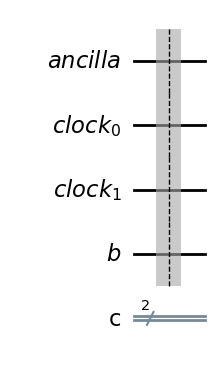

In [158]:
clock = QuantumRegister(2, name='clock')
input_reg = QuantumRegister(1, name='b')
ancilla = QuantumRegister(1, name='ancilla')
measurement = ClassicalRegister(2, name='c')
circuit = QuantumCircuit(ancilla, clock, input_reg, measurement)

circuit.barrier()
circuit.draw(output='mpl')

In [159]:
def qft_dagger(circ, q, n):      
    circ.h(clock[1])
    for j in reversed(range(n)):
      for k in reversed(range(j+1,n)):
        circ.cp(-np.pi/float(2**(k-j)), q[k], q[j])
    circ.h(clock[0])
    circ.swap(clock[0], clock[1])

def qft(circ, q, n):
    circ.swap(clock[0], clock[1])
    circ.h(clock[0])
    for j in reversed(range(n)):
      for k in reversed(range(j+1,n)):
        circ.cp(np.pi/float(2**(k-j)), q[k], q[j])
    circ.h(clock[1])

In [160]:
def qpe(circ, clock, target):
    circ.barrier()
    circ.cu(np.pi, 0, np.pi, np.pi/2, clock[0], target, label='U')
    circ.cu(0, 0, 0, np.pi, clock[1], target, label='U2')
    circ.barrier()
    qft_dagger(circ, clock, 2)
    
def inv_qpe(circ, clock, target):
    qft(circ, clock, 2)
    circ.barrier()
    circ.cu(0, 0, 0, np.pi, clock[1], target, label='U2_inv')
    circ.cu(np.pi, 0, -np.pi, (3/2)*np.pi, clock[0], target, label='U_inv')
    circ.barrier()

In [161]:
def hhl(circ, ancilla, clock, input, measurement):
    
    qpe(circ, clock, input)

    circ.barrier()
    ccRy1=qulib.RYGate(np.pi).control(2, ctrl_state='01')
    circ.append(ccRy1,[clock[0],clock[1],ancilla])
    ccRy2=qulib.RYGate(2 * np.arcsin(1/3)).control(2, ctrl_state='11')
    circ.append(ccRy2,[clock[0],clock[1],ancilla])
    circ.barrier()
    
    circ.measure(ancilla, measurement[0])
    circ.barrier()
    inv_qpe(circ, clock, input)

In [162]:
(11/50)*np.pi

0.6911503837897545

In [163]:
circuit.initialize(b, 3)
circuit.barrier()
circuit.h(clock)
hhl(circuit, ancilla, clock, input_reg, measurement)
circuit.h(clock)
circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "ancilla"), index=0>, <Qubit register=(2, "clock"), index=0>, <Qubit register=(2, "clock"), index=1>, <Qubit register=(1, "b"), index=0>), clbits=())

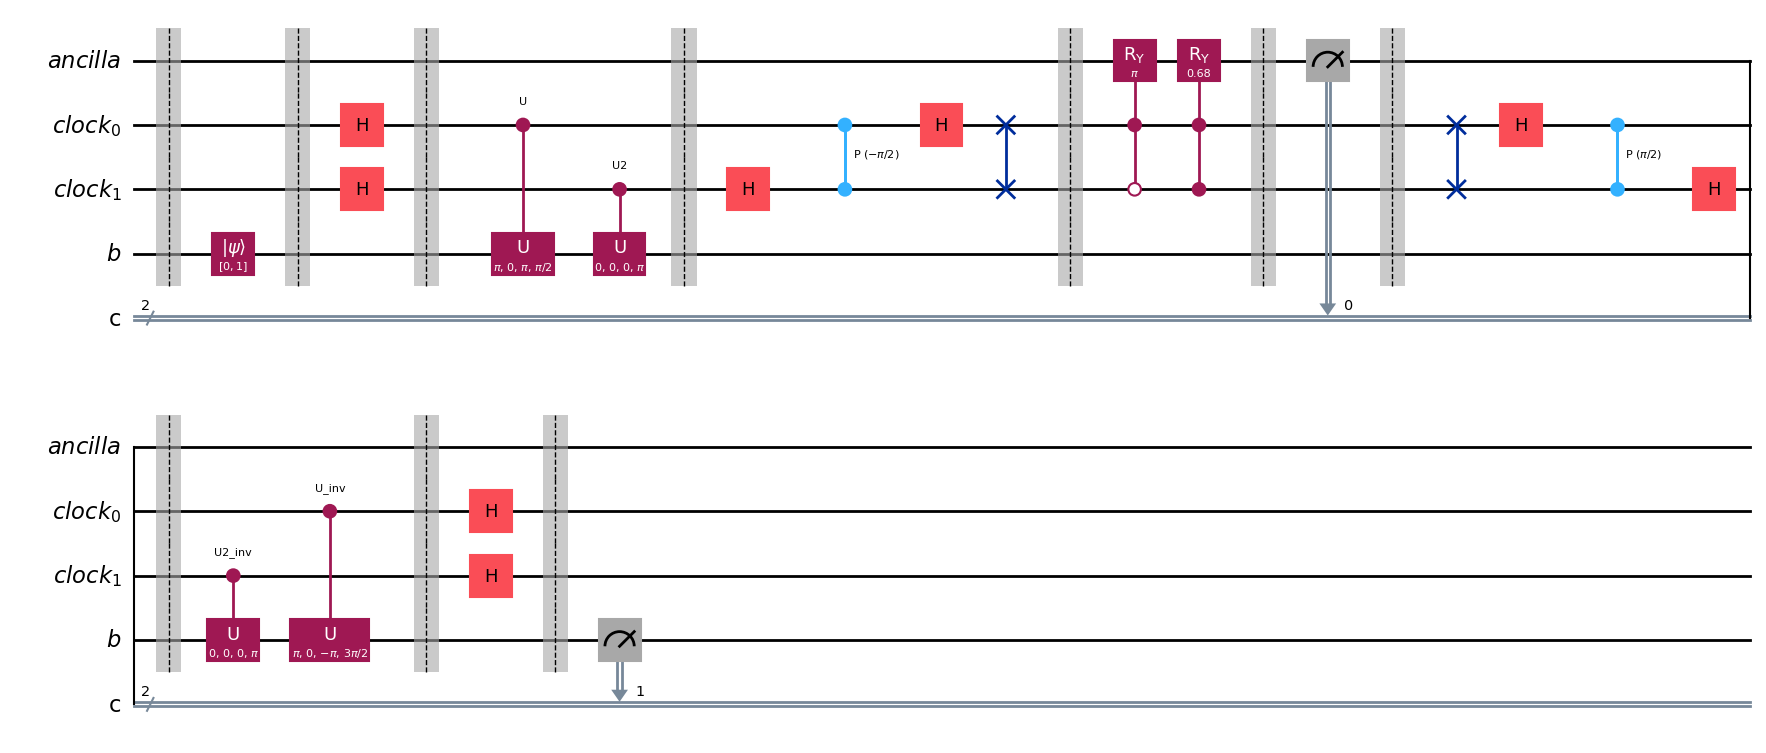

In [164]:
circuit.measure(input_reg, measurement[1])
circuit.draw('mpl',scale=1)

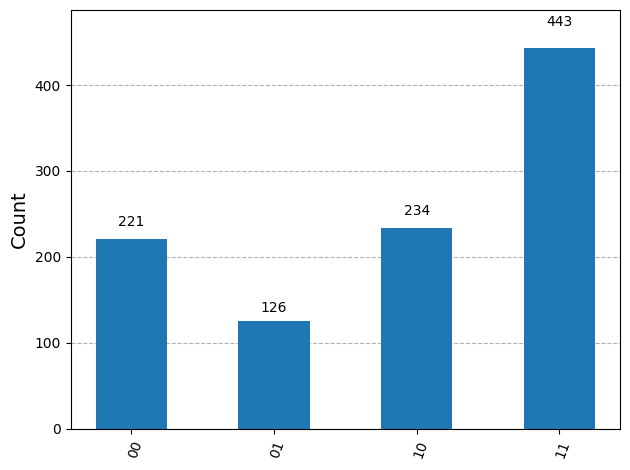

In [165]:
probe=1024
simulator = AerSimulator()
transpiled_circuit = transpile(circuit, simulator)
job = simulator.run(transpiled_circuit, shots=probe)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

## Task 2: Amplitudes Analysis

In [166]:
x = np.linalg.solve(A, b)
x

array([0.33333333, 0.66666667])

In [167]:
classical_ratio = float(x[0]/x[1])
classical_ratio

0.5

In [171]:
ancilla_1 = [key for key in counts if key[1] == "1"]
filtered_counts = {key: counts[key] for key in ancilla_1}

quantum_ratio = filtered_counts["01"] / filtered_counts["11"]
float(np.sqrt(quantum_ratio))

0.5333145218653863

## Task 3: Probability Analysis

In [169]:
classical_ratio_probability = float((x[0]*x[0])/(x[1]*x[1]))
classical_ratio_probability

0.25

In [170]:
quantum_ratio

0.28442437923250563

## Conclusions

In this study, the implementation of the HHL algorithm successfully demonstrated its core functionality by producing a ratio of amplitudes and probabilities that closely mirrors classical results. These findings confirm that, even on a small scale, the algorithm can accurately encode and process linear systems within a quantum framework. The results validate the use of quantum algorithms for the problem of solving linear sets of equations.